1. Import the libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

2. Load the dataset

In [89]:
data = pd.read_csv(r"C:\Users\Admin\Downloads\houseprice.csv")

print(data.head())


   Area  Bedrooms  Bathrooms  Location  Property_Age     Price
0  1200         2          2     Urban             5   5500000
1  1500         3          2     Urban             3   7200000
2  1800         3          3     Urban             2   8500000
3  2400         4          3     Urban             1  12000000
4  1000         2          1  Suburban            10   4200000


3. Check for missing values

In [57]:
print(data.isnull().sum())

Area            0
Bedrooms        0
Bathrooms       0
Location        0
Property_Age    0
Price           0
dtype: int64


4. Convert the Location column to numeric

In [59]:
data = pd.get_dummies(data, columns=["Location"], drop_first=True)

5. Separate features and target

In [61]:
X = data.drop("Price", axis=1)
y = data["Price"]

6. Split the dataset

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

7. Train the Linear Regression model

In [65]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

8. Evaluate the Linear Regression model

In [67]:
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

Linear Regression
MAE : 536623.370932689
MSE : 511946082251.8883
RMSE : 715504.0756361128
R2 Score : 0.96239147237819


9. Train the Decision Tree model

In [69]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [71]:
print("Decision Tree")
print("MAE :", mean_absolute_error(y_test, y_pred_dt))
print("MSE :", mean_squared_error(y_test, y_pred_dt))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score :", r2_score(y_test, y_pred_dt))

Decision Tree
MAE : 737500.0
MSE : 708750000000.0
RMSE : 841872.9120241369
R2 Score : 0.9479338842975207


10. Train the Random Forest model

In [73]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [75]:
print("Random Forest")
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("MSE :", mean_squared_error(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score :", r2_score(y_test, y_pred_rf))

Random Forest
MAE : 525625.0
MSE : 348459625000.0
RMSE : 590304.6882754702
R2 Score : 0.9744014967860423


11. Compare actual and predicted prices

In [77]:
result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred_rf
})

print(result.head(10))

    Actual Price  Predicted Price
19       5600000        6089000.0
16      13200000       13928000.0
15      10500000       10485000.0
26       4700000        4247000.0
4        4200000        3665000.0
12      14500000       13490000.0
37       7900000        8262000.0
27       6200000        5587000.0


12. Plot the results

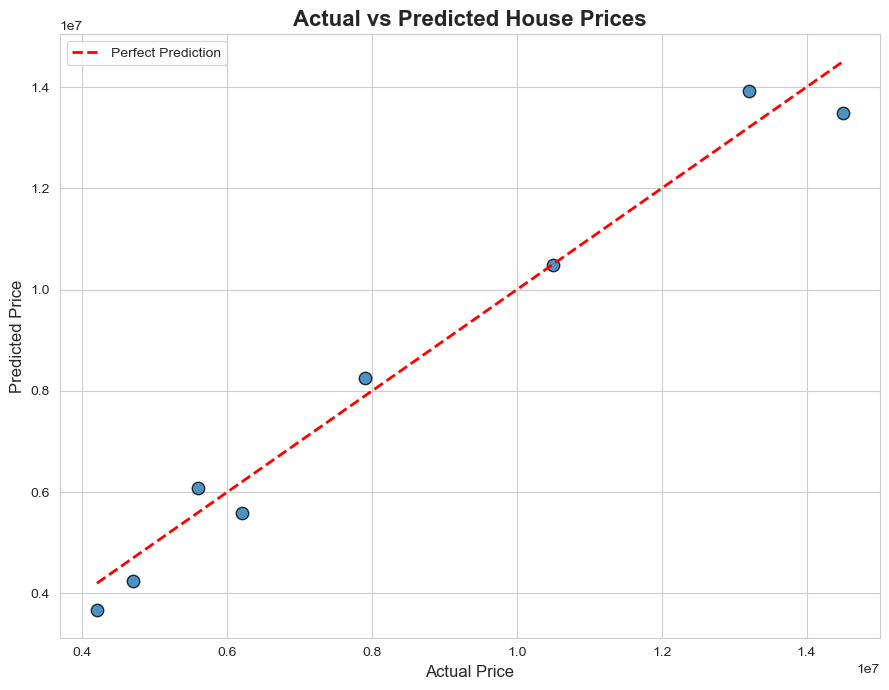

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(9,7))

plt.scatter(
    y_test,
    y_pred_rf,
    color="#1f77b4",
    edgecolors="black",
    alpha=0.8,
    s=80
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Price", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)
plt.title("Actual vs Predicted House Prices", fontsize=16, fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

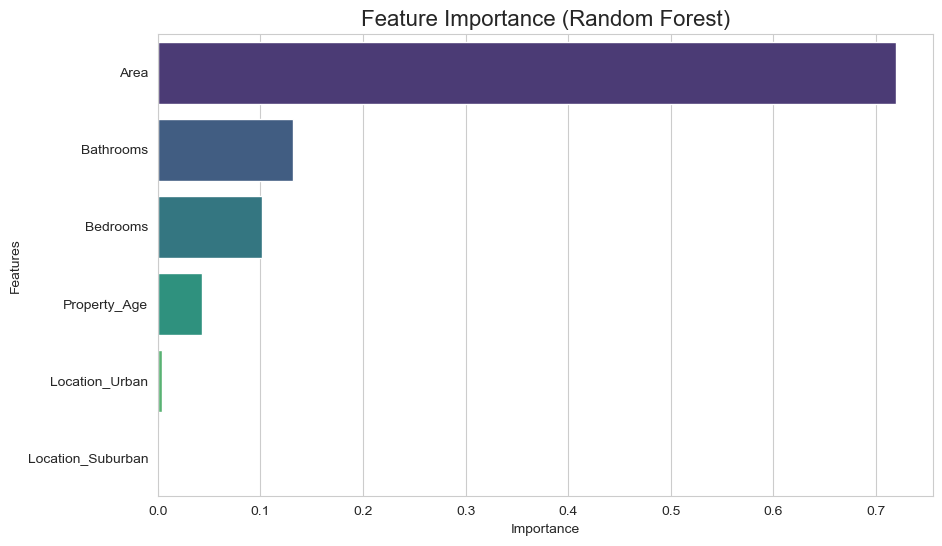

In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance (Random Forest)", fontsize=16)
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

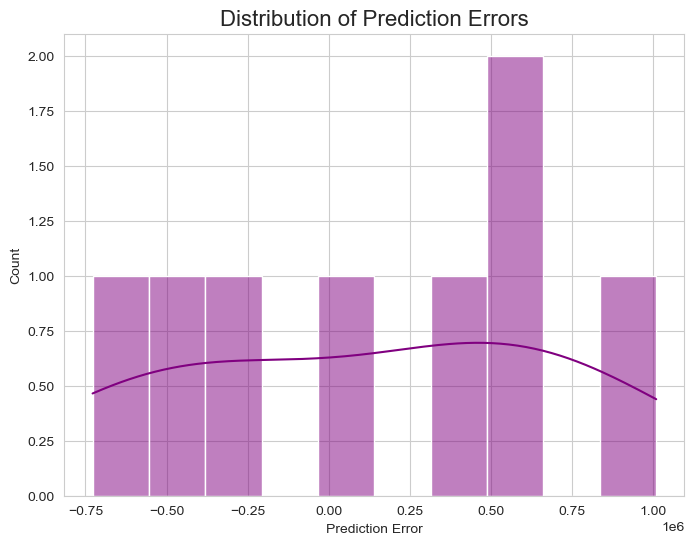

In [97]:
errors = y_test - y_pred_rf

plt.figure(figsize=(8,6))

sns.histplot(errors, bins=10, kde=True, color="purple")

plt.title("Distribution of Prediction Errors", fontsize=16)
plt.xlabel("Prediction Error")
plt.ylabel("Count")

plt.show()

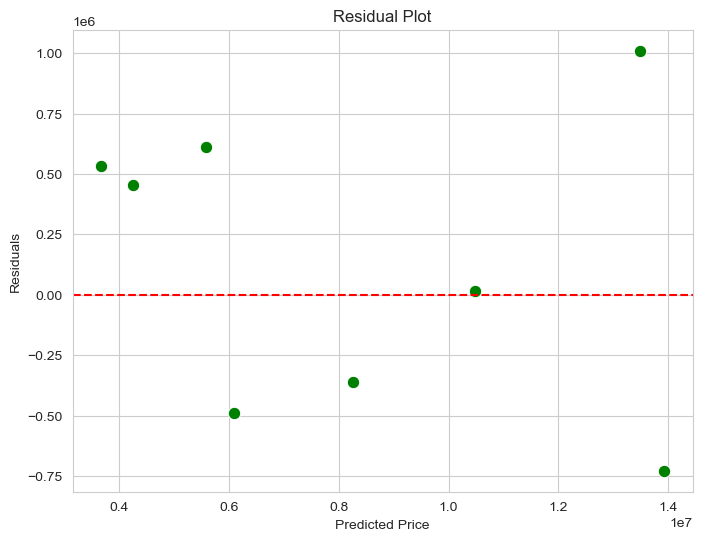

In [99]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred_rf,
    y=y_test - y_pred_rf,
    color="green",
    s=80
)

plt.axhline(0, color="red", linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.show()

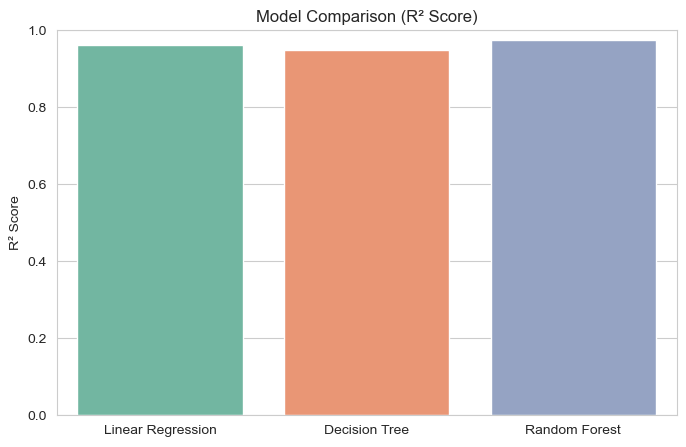

In [105]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr_r2 = r2_score(y_test, y_pred_lr)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
dt_r2 = r2_score(y_test, y_pred_dt)

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x=models,
    y=r2_scores,
    hue=models,        # add this
    palette="Set2",
    legend=False       # remove duplicate legend
)

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.show()